# Particle Filters for Data Assimilation

This notebook studies sequential importance sampling and resampling methods for filtering. See Chapter 6, Section 6.3.6: Bootstrap Particle Filter; Chapter 6, Section 6.3.7: Optimal Particle Filter; and Chapter 6, Section 6.3.8: Evaluating Probabilistic Estimation.

## 1. Unified notation and two canonical testbeds

We use the standard hidden-state model
$$
\begin{aligned}
v_{j+1}^{\dagger} &= \Psi(v_j^{\dagger}) + \xi_j^{\dagger}, \quad
\xi_j^{\dagger} \sim \mathcal N(0,\Sigma), \\
y_{j+1}^{\dagger} &= h(v_{j+1}^{\dagger}) + \eta_{j+1}^{\dagger}, \quad
\eta_{j+1}^{\dagger} \sim \mathcal N(0,\Gamma).
\end{aligned}
$$
with observation history and filtering measures
$$
\begin{aligned}
&Y_j^{\dagger} = \{y_1^{\dagger},\dots,y_j^{\dagger}\}, \quad
\pi_j = \mathbb P(v_j^{\dagger}\mid Y_j^{\dagger}), \\
&\widehat\pi_{j+1} = \mathsf{P}\pi_j, \quad
\pi_{j+1} = \mathsf{A}_{j+1}\widehat\pi_{j+1}.
\end{aligned}
$$
and regularity assumptions $\Psi\in C^1(\mathbb R^d,\mathbb R^d),\ h\in C^1(\mathbb R^d,\mathbb R^k)$.


### 1.1 Test Dataset 1: Linear-Gaussian, d=2
$$
\begin{aligned}
v_{j+1} &= A v_j + \xi_j, \quad \xi_j \sim \mathcal N(0,\Sigma),\\
y_j &= H v_j + \eta_j, \quad \eta_j \sim \mathcal N(0,\Gamma).
\end{aligned}
$$
where
$$
A(\theta)=\begin{bmatrix}\cos\theta & -\sin\theta\\ \sin\theta & \cos\theta\end{bmatrix},
\qquad A^TA=I.
$$

Observation for this testbed is the first state component:
$$
h(v)=v_1,
\qquad H=\begin{bmatrix}1 & 0\end{bmatrix}.
$$

### 1.2 Test Dataset 2: Lorenz 63
$$
\begin{aligned}
\dot x &= \sigma(y-x), \\
\dot y &= x(\rho-z)-y, \\
\dot z &= xy-\beta z,
\end{aligned}
\qquad (\sigma,\rho,\beta)=\left(10,28,\frac{8}{3}\right).
$$
For Lorenz-63, we also observe the first state component only:
$$
h([x,y,z]^T)=x.
$$

### 1.3 DA Parameters and Numerical Details

#### Initial condition setup:

For the linear model, we take
$$
v_0 \sim \mathcal{N}(m_0, I),
$$
where the center can be a random initial point, e.g.
$$
m_0 \sim \mathcal{N}(0, I).
$$

For Lorenz-63, we use burn-in initialization: sample $m_0 \sim \mathcal{N}(0, I)$, run the model forward for many steps (100 steps here) to get $x_0$, and then set
$$
v_0 \sim \mathcal{N}(x_0, I).
$$
The burn-in trajectory is used only to choose the initial state; it is not included in the returned truth trajectory or in any plots.


#### Noise levels
$$
\Sigma = \sigma_v^2 I,
\qquad \sigma_v = 0.01,
$$
$$
\Gamma = \sigma_y^2 I,
\qquad \sigma_y = 1.
$$

#### Numerical integral:
For Lorenz 63:
$$
\Delta t = 0.15 \quad \text{(assimilation time step)},
$$
$$
dt = 0.03 \quad \text{(integration time step, RK4 scheme)}.
$$


## 2. Particle filters

At time step $j$, we assume the filtering measure $\pi_j$ is approximated by a set of $N$ **equally weighted** particles $\{v_j^{(n)}\}_{n=1}^N$:
$$
\pi_j \approx \pi_j^N = \frac{1}{N} \sum_{n=1}^N \delta_{v_j^{(n)}}.
$$
Our goal is to approximate the next filtering distribution $\pi_{j+1} = \mathbb{P}(v_{j+1}^{\dagger} \mid Y_{j+1}^{\dagger})$ by a new set of particles $\{v_{j+1}^{(n)}\}_{n=1}^N$. Since we cannot sample from the target $\pi_{j+1}$ directly, we use Importance Sampling. This involves introducing a proposal distribution $q(v_{j+1} \mid v_j^{(n)}, y_{j+1})$, an easy-to-sample density that guides the particles toward regions of high posterior probability.

### 2.1 Bootstrap Particle Filter (BPF)
The BPF is the most straightforward implementation of the sequential importance sampling and resampling (SIR) framework. It uses the transition prior as the proposal distribution.

1.  **Propagation:** For each particle $n$, sample a candidate from the transition density:
$$
\hat{v}_{j+1}^{(n)} \sim p(v_{j+1} \mid v_j^{(n)}) = \mathcal{N}(\Psi(v_j^{(n)}), \Sigma).
$$
2.  **Weighting:** Assign importance weights based on the likelihood of the new observation $y_{j+1}$:
$$
w_{j+1}^{(n)} \propto p(y_{j+1} \mid \hat{v}_{j+1}^{(n)}) = \mathcal{N}(y_{j+1}; h(\hat{v}_{j+1}^{(n)}), \Gamma).
$$
3.  **Resampling:** Sample $N$ new particles $\{v_{j+1}^{(n)}\}_{n=1}^N$ from the set $\{\hat{v}_{j+1}^{(k)}\}_{k=1}^N$ with probabilities proportional to $w_{j+1}^{(k)}$. After resampling, the particles are again equally weighted with $1/N$.



### 2.2 Optimal Particle Filter (OPF)
The weights in BPF often become unevenly distributed (high variance) because the proposal does not account for the current observation $y_{j+1}$. The OPF addresses this by choosing a proposal that minimizes the variance of the incremental weights:
$$
q^\star(v_{j+1} \mid v_j^{(n)}, y_{j+1}) = p(v_{j+1} \mid v_j^{(n)}, y_{j+1}).
$$

#### 2.2.1 Linear-Gaussian Case
For the linear model (Test Dataset 1), the optimal proposal is Gaussian and can be computed in closed form:
$$
q^\star(v_{j+1} \mid v_j^{(n)}, y_{j+1}) = \mathcal{N}(m_{j+1}^{(n)}, C^\star),
$$
$$
C^\star = (\Sigma^{-1} + H^T \Gamma^{-1} H)^{-1}, \quad m_{j+1}^{(n)} = C^\star (\Sigma^{-1} \Psi(v_j^{(n)}) + H^T \Gamma^{-1} y_{j+1}).
$$
The incremental weights are proportional to the predictive likelihood:
$$
w_{j+1}^{(n)} \propto p(y_{j+1} \mid v_j^{(n)}) = \mathcal{N}(y_{j+1}; h(\Psi(v_j^{(n)})), H \Sigma H^T + \Gamma).
$$

#### 2.2.2 General Case (Nonlinear Approximation)
For nonlinear models like Lorenz-63, the optimal proposal is usually intractable. A common approach is to approximate $p(v_{j+1} \mid v_j^{(n)}, y_{j+1})$ with a local Gaussian centered at the MAP (3DVar) point:
$$
\hat{v}_{j+1}^{(n)} = \arg \min_v \left( \frac{1}{2} \| v - \Psi(v_j^{(n)}) \|_{\Sigma}^2 + \frac{1}{2} \| y_{j+1} - h(v) \|_{\Gamma}^2 \right).
$$
The proposal is then $\mathcal{N}(\hat{v}_{j+1}^{(n)}, \hat{C}_n)$, where $\hat{C}_n$ is the inverse Hessian of the objective function.

### 2.3 Auxiliary Particle Filter (APF)
The APF introduces a "look-ahead" mechanism to identify promising ancestors before the propagation step. It effectively changes the order of operations by resampling based on a proxy of the future likelihood.

#### 2.3.1 Stage 1: Ancestor Selection
We first evaluate the potential of each current particle $v_j^{(n)}$ by using a point estimate (proxy) of its future state, such as the mean transition $\bar{v}_{j+1}^{(n)} = \Psi(v_j^{(n)})$. We calculate ancestor scores:
$$
\tilde{w}_j^{(n)} \propto \frac{1}{N} p(y_{j+1} \mid \bar{v}_{j+1}^{(n)}) = \frac{1}{N} \mathcal{N}(y_{j+1}; h(\Psi(v_j^{(n)})), \Gamma).
$$
We then resample $N$ ancestor indices $\{a^{(n)}\}_{n=1}^N$ from $\{1, \dots, N\}$ according to these scores $\tilde{w}_j$. This ensures we only propagate particles that are likely to be consistent with $y_{j+1}$.

#### 2.3.2 Stage 2: Propagation and Correction
For each selected ancestor index $a^{(n)}$, we sample the new state from the transition prior:
$$
v_{j+1}^{(n)} \sim p(v_{j+1} \mid v_j^{(a^{(n)})}) = \mathcal{N}(\Psi(v_j^{(a^{(n)})}), \Sigma).
$$
Because the ancestors were selected using the proxy $\bar{v}_{j+1}$, we must apply a correction weight to maintain a consistent approximation of the filtering measure $\pi_{j+1}$:
$$
w_{j+1}^{(n)} \propto \frac{p(y_{j+1} \mid v_{j+1}^{(n)})}{p(y_{j+1} \mid \bar{v}_{j+1}^{(a^{(n)})})}.
$$
This weight adjusts for the discrepancy between the actual sample $v_{j+1}^{(n)}$ and the look-ahead proxy $\bar{v}_{j+1}$ used in Stage 1.

## 3. Linear Gaussian experiment

**Parameter exploration.**

- `n_particles`: Increasing the number of particles usually reduces Monte Carlo variability, although the three filters can still differ because the proposal distributions are different.
- `observation_noise_std`: Smaller observation noise makes the likelihood sharper, so weights become more concentrated and proposal design matters more.
- `use_true_initialization`: Turning this off starts the filter from a deliberately perturbed center, so early estimates should need several analysis steps to recover.

**Recommended test combinations.** Keep unspecified controls at their displayed defaults.

| `n_particles` | `observation_noise_std` | `use_true_initialization` |
|---:|---:|:---:|
| 50 | 1.0 | True |
| 500 | 1.0 | True |
| 50 | 1.0 | False |
| 500 | 1.0 | False |

Effective parameters:
  steps: 80
  theta: 0.3
  dynamics_noise_std: 0.01
  observation_noise_std: 1.0
  n_particles: 50
  use_true_initialization: True
  seed: 42

RMSE by method:
  Bootstrap: 0.263
  Optimal: 0.206
  Auxiliary: 0.328


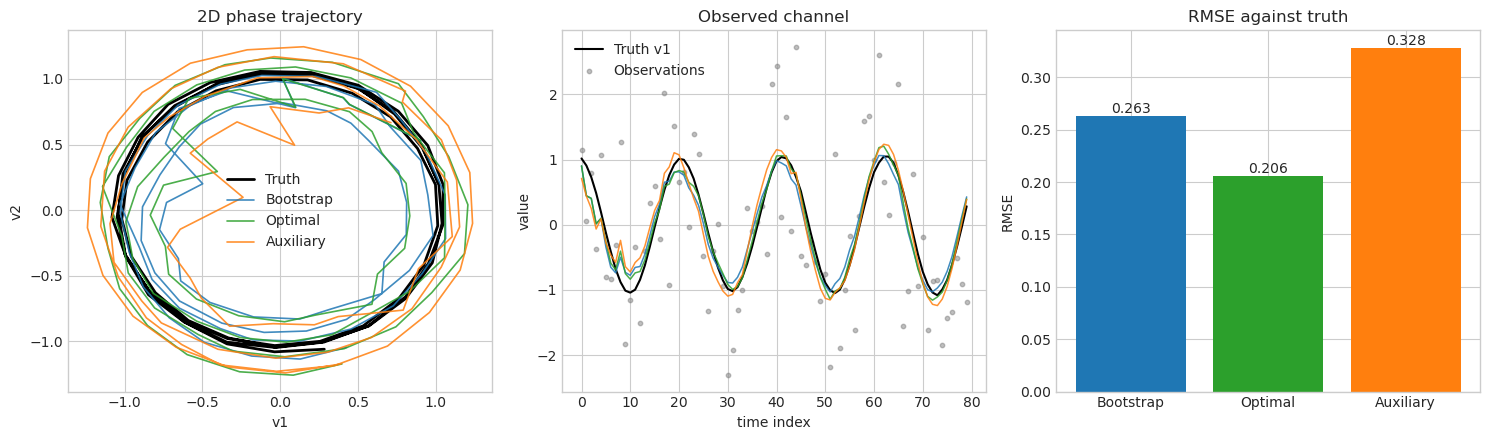

In [1]:
#@title Linear Gaussian particle-filter comparison
try:
    import torch
except ImportError:
    torch = None
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
np.set_printoptions(precision=4, suppress=True)

TORCH_AVAILABLE = torch is not None
TORCH_GPU_AVAILABLE = bool(TORCH_AVAILABLE and torch.cuda.is_available())
TORCH_DEVICE = torch.device("cuda") if TORCH_GPU_AVAILABLE else (torch.device("cpu") if TORCH_AVAILABLE else None)
TORCH_DTYPE = torch.float64 if TORCH_AVAILABLE else None


def as_torch(x, device=None, dtype=None):
    if not TORCH_AVAILABLE:
        raise RuntimeError("PyTorch is not available in this environment.")
    if device is None:
        device = TORCH_DEVICE
    if dtype is None:
        dtype = TORCH_DTYPE
    return torch.as_tensor(x, device=device, dtype=dtype)


def symmetrize_torch(M):
    return 0.5 * (M + M.T)


def mvn_sample_torch(mean, cov, size=None, generator=None, eps=1e-9):
    mean = as_torch(mean)
    cov = as_torch(cov, device=mean.device, dtype=mean.dtype)
    cov = symmetrize_torch(cov)
    w, V = torch.linalg.eigh(cov)
    w = torch.clamp(w, min=eps)
    sqrt_cov = (V * torch.sqrt(w)) @ V.T
    d = mean.shape[0]
    if size is None:
        z = torch.randn(d, device=mean.device, dtype=mean.dtype, generator=generator)
        return mean + sqrt_cov @ z
    z = torch.randn((size, d), device=mean.device, dtype=mean.dtype, generator=generator)
    return z @ sqrt_cov.T + mean


def gaussian_logpdf_torch(x, mean, cov):
    x = as_torch(x).reshape(-1)
    mean = as_torch(mean, device=x.device, dtype=x.dtype).reshape(-1)
    cov = as_torch(cov, device=x.device, dtype=x.dtype)
    cov = symmetrize_torch(cov)
    d = x.shape[0]
    xc = x - mean
    sign, logdet = torch.linalg.slogdet(cov)
    if sign.item() <= 0:
        cov = cov + 1e-9 * torch.eye(cov.shape[0], device=cov.device, dtype=cov.dtype)
        _, logdet = torch.linalg.slogdet(cov)
    quad = xc @ torch.linalg.pinv(cov) @ xc
    const = torch.log(torch.tensor(2.0 * np.pi, device=x.device, dtype=x.dtype))
    return -0.5 * (d * const + logdet + quad)


def gaussian_logpdf_batch_torch(x, means, cov):
    means = as_torch(means)
    x = as_torch(x, device=means.device, dtype=means.dtype).reshape(1, -1)
    cov = as_torch(cov, device=means.device, dtype=means.dtype)
    cov = symmetrize_torch(cov)

    d = means.shape[1]
    xc = means - x
    sign, logdet = torch.linalg.slogdet(cov)
    if sign.item() <= 0:
        cov = cov + 1e-9 * torch.eye(cov.shape[0], device=cov.device, dtype=cov.dtype)
        _, logdet = torch.linalg.slogdet(cov)
    cov_inv = torch.linalg.pinv(cov)
    quad = torch.sum((xc @ cov_inv) * xc, dim=1)
    const = torch.log(torch.tensor(2.0 * np.pi, device=means.device, dtype=means.dtype))
    return -0.5 * (d * const + logdet + quad)


def normalize_logweights_torch(logw):
    m = torch.max(logw)
    w = torch.exp(logw - m)
    s = torch.sum(w)
    if (not torch.isfinite(s).item()) or (s.item() <= 0):
        return torch.ones_like(logw) / logw.numel()
    return w / s


def systematic_resample_torch(weights, generator=None):
    n = weights.numel()
    u0 = torch.rand((), device=weights.device, dtype=weights.dtype, generator=generator)
    u = (u0 + torch.arange(n, device=weights.device, dtype=weights.dtype)) / n
    cdf = torch.cumsum(weights, dim=0)
    idx = torch.searchsorted(cdf, u, right=True)
    return torch.clamp(idx, 0, n - 1).long()


def lorenz63_rhs_torch(x, sigma=10.0, rho=28.0, beta=8.0 / 3.0):
    xx = x[..., 0]
    yy = x[..., 1]
    zz = x[..., 2]
    return torch.stack([
        sigma * (yy - xx),
        xx * (rho - zz) - yy,
        xx * yy - beta * zz,
    ], dim=-1)


def lorenz63_step_torch(x, dt=0.03):
    k1 = lorenz63_rhs_torch(x)
    k2 = lorenz63_rhs_torch(x + 0.5 * dt * k1)
    k3 = lorenz63_rhs_torch(x + 0.5 * dt * k2)
    k4 = lorenz63_rhs_torch(x + dt * k3)
    return x + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)



def symmetrize(M):
    return 0.5 * (M + M.T)


def sqrtm_psd(M, eps=1e-12):
    w, V = np.linalg.eigh(symmetrize(M))
    w = np.clip(w, eps, None)
    return (V * np.sqrt(w)) @ V.T


def invsqrtm_psd(M, eps=1e-12):
    w, V = np.linalg.eigh(symmetrize(M))
    w = np.clip(w, eps, None)
    return (V * (1.0 / np.sqrt(w))) @ V.T


def gaussian_logpdf(x, mean, cov):
    x = np.atleast_1d(x)
    mean = np.atleast_1d(mean)
    cov = np.atleast_2d(cov)
    d = x.shape[0]
    xc = x - mean
    sign, logdet = np.linalg.slogdet(cov)
    if sign <= 0:
        cov = cov + 1e-9 * np.eye(cov.shape[0])
        sign, logdet = np.linalg.slogdet(cov)
    quad = xc @ np.linalg.pinv(cov) @ xc
    return -0.5 * (d * np.log(2.0 * np.pi) + logdet + quad)


def normalize_logweights(logw):
    m = np.max(logw)
    w = np.exp(logw - m)
    s = np.sum(w)
    if (not np.isfinite(s)) or s <= 0:
        return np.ones_like(logw) / len(logw)
    return w / s


def systematic_resample(weights, rng):
    n = len(weights)
    u = (rng.random() + np.arange(n)) / n
    cdf = np.cumsum(weights)
    idx = np.searchsorted(cdf, u, side="right")
    return np.clip(idx, 0, n - 1)


def make_rotation(theta):
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[c, -s], [s, c]])


def sample_linear_initial(rng, d=2):
    m0 = rng.multivariate_normal(np.zeros(d), np.eye(d))
    v0 = rng.multivariate_normal(m0, np.eye(d))
    return v0, m0


def simulate_linear_gaussian_2d(T=80, theta=0.3, sigma_v=0.01, sigma_y=1.0, seed=0):
    rng = np.random.default_rng(seed)
    A = make_rotation(theta)
    H = np.array([[1.0, 0.0]])
    Sigma = (sigma_v ** 2) * np.eye(2)
    Gamma = np.array([[sigma_y ** 2]])

    truth = np.zeros((T, 2))
    obs = np.zeros((T, 1))

    v, _ = sample_linear_initial(rng, d=2)
    for k in range(T):
        v = A @ v + rng.multivariate_normal(np.zeros(2), Sigma)
        y = H @ v + rng.multivariate_normal(np.zeros(1), Gamma)
        truth[k] = v
        obs[k] = y

    return truth, obs, A, H, Sigma, Gamma


def lorenz63_rhs(x, sigma=10.0, rho=28.0, beta=8.0 / 3.0):
    xx, yy, zz = x
    return np.array([
        sigma * (yy - xx),
        xx * (rho - zz) - yy,
        xx * yy - beta * zz,
    ])


def lorenz63_step(x, dt=0.03):
    k1 = lorenz63_rhs(x)
    k2 = lorenz63_rhs(x + 0.5 * dt * k1)
    k3 = lorenz63_rhs(x + 0.5 * dt * k2)
    k4 = lorenz63_rhs(x + dt * k3)
    return x + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)


def lorenz63_burnin_initial(rng, dt=0.03, burn_steps=100):
    m0 = rng.multivariate_normal(np.zeros(3), np.eye(3))
    x = m0.copy()
    for _ in range(burn_steps):
        x = lorenz63_step(x, dt)
    x0 = x.copy()
    v0 = rng.multivariate_normal(x0, np.eye(3))
    return v0, m0, x0


def simulate_lorenz63(T=10.0, dt=0.03, Delta_t=0.15, sigma_v=0.01, sigma_y=1.0, burn_steps=100, seed=0):
    rng = np.random.default_rng(seed)
    n_steps = max(int(T / dt), 1)

    truth = np.zeros((n_steps, 3))
    x, _, _ = lorenz63_burnin_initial(rng, dt=dt, burn_steps=burn_steps)

    for t in range(n_steps):
        x = lorenz63_step(x, dt)
        if sigma_v > 0:
            x = x + rng.normal(0.0, sigma_v, size=3)
        truth[t] = x

    obs_gap = max(int(round(Delta_t / dt)), 1)
    obs_idx = [0]  # Observe first dimension only
    obs_times = np.arange(obs_gap, n_steps, obs_gap)
    Gamma = (sigma_y ** 2) * np.eye(len(obs_idx))
    obs = truth[obs_times][:, obs_idx] + rng.multivariate_normal(np.zeros(len(obs_idx)), Gamma, size=len(obs_times))

    return truth, obs, obs_times, obs_idx


# -------------------------------------------------------------------------
# Particle Filter Runners (using your provided helper functions)
# -------------------------------------------------------------------------

def run_pf_linear_torch(obs, A, H, Sigma, Gamma, N, method, use_true_init, truth_x0, seed, progress_bar=None):
    device = torch.device("cuda")
    torch.manual_seed(int(seed))
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(int(seed))

    obs_t = as_torch(obs, device=device)
    A_t = as_torch(A, device=device)
    H_t = as_torch(H, device=device)
    Sigma_t = as_torch(Sigma, device=device)
    Gamma_t = as_torch(Gamma, device=device)
    truth_x0_t = as_torch(truth_x0, device=device)

    T = obs_t.shape[0]
    d = A_t.shape[0]

    if use_true_init:
        particles = mvn_sample_torch(truth_x0_t, torch.eye(d, device=device, dtype=obs_t.dtype), size=N)
    else:
        epsilon = torch.randn(d, device=device, dtype=obs_t.dtype)
        perturbed_x0 = truth_x0_t * (1.0 + 0.3 * epsilon)
        particles = mvn_sample_torch(perturbed_x0, torch.eye(d, device=device, dtype=obs_t.dtype), size=N)

    weights = torch.full((N,), 1.0 / N, device=device, dtype=obs_t.dtype)
    est = torch.zeros((T, d), device=device, dtype=obs_t.dtype)

    Sigma_inv = torch.linalg.pinv(Sigma_t)
    Gamma_inv = torch.linalg.pinv(Gamma_t)
    C_opt = torch.linalg.pinv(Sigma_inv + H_t.T @ Gamma_inv @ H_t)
    S_pred = H_t @ Sigma_t @ H_t.T + Gamma_t

    zeros_d = torch.zeros(d, device=device, dtype=obs_t.dtype)

    for k in range(T):
        y = obs_t[k].reshape(-1)

        if method == "bootstrap":
            pred_mean = particles @ A_t.T
            prop = pred_mean + mvn_sample_torch(zeros_d, Sigma_t, size=N)
            logw = torch.log(weights + 1e-300)
            logw = logw + gaussian_logpdf_batch_torch(y, prop @ H_t.T, Gamma_t)
            particles = prop

        elif method == "optimal":
            prev = particles.clone()
            pred_mean = prev @ A_t.T
            prop = torch.zeros_like(prev)
            logw = torch.log(weights + 1e-300)
            obs_term = H_t.T @ Gamma_inv @ y

            for i in range(N):
                m_star = C_opt @ (Sigma_inv @ pred_mean[i] + obs_term)
                prop[i] = mvn_sample_torch(m_star, C_opt)

            logw = logw + gaussian_logpdf_batch_torch(y, pred_mean @ H_t.T, S_pred)
            particles = prop

        elif method == "auxiliary":
            prev = particles.clone()
            pred_mean = prev @ A_t.T

            first_logw = torch.log(weights + 1e-300)
            first_logw = first_logw + gaussian_logpdf_batch_torch(y, pred_mean @ H_t.T, S_pred)
            first_w = normalize_logweights_torch(first_logw)
            ancestors = torch.multinomial(first_w, N, replacement=True)

            anc_mean = pred_mean[ancestors]
            prop = anc_mean + mvn_sample_torch(zeros_d, Sigma_t, size=N)

            logw = gaussian_logpdf_batch_torch(y, prop @ H_t.T, Gamma_t)
            logw = logw - gaussian_logpdf_batch_torch(y, anc_mean @ H_t.T, S_pred)
            particles = prop
        else:
            raise ValueError(f"Unknown method: {method}")

        weights = normalize_logweights_torch(logw)
        est[k] = torch.sum(weights[:, None] * particles, dim=0)

        ess = 1.0 / torch.sum(weights ** 2)
        if ess.item() < 0.5 * N:
            idx = systematic_resample_torch(weights)
            particles = particles[idx]
            weights.fill_(1.0 / N)

        if progress_bar:
            progress_bar.value += 1

    return est.detach().cpu().numpy()


def run_pf_linear(obs, A, H, Sigma, Gamma, N, method, use_true_init, truth_x0, seed, progress_bar=None):
    """
    Particle Filter for Linear-Gaussian system using provided helper functions.
    input: obs (T, d_obs), system matrices, N (particles), method (str), init flags, truth_x0 (d,), seed
    output: est (T, d) state estimates
    """
    if TORCH_GPU_AVAILABLE:
        return run_pf_linear_torch(obs, A, H, Sigma, Gamma, N, method, use_true_init, truth_x0, seed, progress_bar=progress_bar)

    rng = np.random.default_rng(seed)
    T = len(obs)
    d = A.shape[0]

    # Initialization
    if use_true_init:
        # N(v0, I)
        particles = rng.multivariate_normal(truth_x0, np.eye(d), size=N)
    else:
        # v0_tilde = v0 * (1 + 0.3 * epsilon), epsilon ~ N(0, I)
        epsilon = rng.standard_normal(size=d)
        perturbed_x0 = truth_x0 * (1 + 0.3 * epsilon)
        particles = rng.multivariate_normal(perturbed_x0, np.eye(d), size=N)

    weights = np.ones(N) / N
    est = np.zeros((T, d))

    # Pre-compute matrices for Optimal PF (Linear Case)
    Sigma_inv = np.linalg.pinv(Sigma)
    Gamma_inv = np.linalg.pinv(Gamma)
    # C_opt: Posterior covariance for the optimal proposal
    C_opt = np.linalg.pinv(Sigma_inv + H.T @ Gamma_inv @ H)
    # S_pred: Predictive covariance p(y_t | x_{t-1})
    S_pred = H @ Sigma @ H.T + Gamma

    for k in range(T):
        y = obs[k]

        # --- Bootstrap PF ---
        if method == "bootstrap":
            # Prediction: x_t = A x_{t-1}
            pred_mean = particles @ A.T
            # Propagate noise
            prop = pred_mean + rng.multivariate_normal(np.zeros(d), Sigma, size=N)

            # Weight update
            logw = np.log(weights + 1e-300)
            for i in range(N):
                logw[i] += gaussian_logpdf(y, H @ prop[i], Gamma)
            particles = prop

        # --- Optimal PF (Exact) ---
        elif method == "optimal":
            prev = particles.copy()
            pred_mean = prev @ A.T
            prop = np.zeros_like(prev)
            logw = np.log(weights + 1e-300)

            for i in range(N):
                # Optimal proposal mean: m* = C_opt (Sigma^-1 A x_{t-1} + H^T Gamma^-1 y_t)
                m_star = C_opt @ (Sigma_inv @ pred_mean[i] + H.T @ Gamma_inv @ y)
                prop[i] = rng.multivariate_normal(m_star, C_opt)

                # Weight update uses predictive density directly
                logw[i] += gaussian_logpdf(y, H @ pred_mean[i], S_pred)
            particles = prop

        # --- Auxiliary PF ---
        elif method == "auxiliary":
            prev = particles.copy()
            pred_mean = prev @ A.T

            # 1. Lookahead / Pilot weights
            first_logw = np.log(weights + 1e-300)
            for i in range(N):
                first_logw[i] += gaussian_logpdf(y, H @ pred_mean[i], S_pred)

            # 2. Resample indices (Auxiliary variable)
            first_w = normalize_logweights(first_logw)
            ancestors = rng.choice(N, size=N, p=first_w)

            anc_mean = pred_mean[ancestors]

            # 3. Propagate
            prop = anc_mean + rng.multivariate_normal(np.zeros(d), Sigma, size=N)

            # 4. Correct weights
            logw = np.zeros(N)
            for i in range(N):
                likelihood = gaussian_logpdf(y, H @ prop[i], Gamma)
                prior = gaussian_logpdf(y, H @ anc_mean[i], S_pred)
                logw[i] = likelihood - prior
            particles = prop

        # Estimate and ESS
        weights = normalize_logweights(logw)
        est[k] = np.sum(weights[:, None] * particles, axis=0)

        # Resampling check
        ess = 1.0 / np.sum(weights ** 2)
        if ess < 0.5 * N:
            idx = systematic_resample(weights, rng)
            particles = particles[idx]
            weights.fill(1.0 / N)

        if progress_bar:
            progress_bar.value += 1

    return est


def run_pf_lorenz_torch(obs, obs_times, obs_idx, dt, sigma_v, sigma_y, N, method, use_true_init, truth_x0, seed, progress_bar=None):
    device = torch.device("cuda")
    torch.manual_seed(int(seed))
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(int(seed))

    T_obs = len(obs)
    d = 3

    H_t = torch.zeros((len(obs_idx), d), device=device, dtype=TORCH_DTYPE)
    for r, c in enumerate(obs_idx):
        H_t[r, c] = 1.0

    Gamma_t = (sigma_y ** 2) * torch.eye(len(obs_idx), device=device, dtype=TORCH_DTYPE)
    Gamma_inv = torch.linalg.pinv(Gamma_t)

    obs_gap = int(obs_times[0]) if len(obs_times) > 0 else 1
    Q_val = max(obs_gap * (sigma_v ** 2), 1e-6)
    Q_t = Q_val * torch.eye(d, device=device, dtype=TORCH_DTYPE)
    Q_inv = torch.linalg.pinv(Q_t)
    C_opt = torch.linalg.pinv(Q_inv + H_t.T @ Gamma_inv @ H_t)
    S_pred = H_t @ Q_t @ H_t.T + Gamma_t

    truth_x0_t = as_torch(truth_x0, device=device, dtype=TORCH_DTYPE)
    if use_true_init:
        particles = mvn_sample_torch(truth_x0_t, torch.eye(d, device=device, dtype=TORCH_DTYPE), size=N)
    else:
        epsilon = torch.randn(d, device=device, dtype=TORCH_DTYPE)
        perturbed_x0 = truth_x0_t * (1.0 + 0.3 * epsilon)
        particles = mvn_sample_torch(perturbed_x0, torch.eye(d, device=device, dtype=TORCH_DTYPE), size=N)

    obs_t = as_torch(obs, device=device, dtype=TORCH_DTYPE)
    weights = torch.full((N,), 1.0 / N, device=device, dtype=TORCH_DTYPE)
    est = torch.zeros((T_obs, d), device=device, dtype=TORCH_DTYPE)
    current_time_step = 0

    for k in range(T_obs):
        target_time_step = int(obs_times[k])
        steps_to_sim = max(target_time_step - current_time_step, 0)
        y = obs_t[k].reshape(-1)

        prev = particles.clone()
        pred_mean = prev.clone()
        for _ in range(steps_to_sim):
            pred_mean = lorenz63_step_torch(pred_mean, dt)

        if method == "bootstrap":
            prop = prev.clone()
            for _ in range(steps_to_sim):
                prop = lorenz63_step_torch(prop, dt)
                if sigma_v > 0:
                    prop = prop + sigma_v * torch.randn_like(prop)

            logw = torch.log(weights + 1e-300)
            logw = logw + gaussian_logpdf_batch_torch(y, prop @ H_t.T, Gamma_t)
            particles = prop

        elif method == "optimal_3dvar":
            prop = torch.zeros_like(prev)
            logw = torch.log(weights + 1e-300)
            obs_term = H_t.T @ Gamma_inv @ y

            for i in range(N):
                m_star = C_opt @ (Q_inv @ pred_mean[i] + obs_term)
                prop[i] = mvn_sample_torch(m_star, C_opt)

            logw = logw + gaussian_logpdf_batch_torch(y, pred_mean @ H_t.T, S_pred)
            particles = prop

        elif method == "auxiliary":
            first_logw = torch.log(weights + 1e-300)
            first_logw = first_logw + gaussian_logpdf_batch_torch(y, pred_mean @ H_t.T, S_pred)

            first_w = normalize_logweights_torch(first_logw)
            ancestors = torch.multinomial(first_w, N, replacement=True)

            anc_mean = pred_mean[ancestors]
            anc_particles = prev[ancestors]

            prop = anc_particles.clone()
            for _ in range(steps_to_sim):
                prop = lorenz63_step_torch(prop, dt)
                if sigma_v > 0:
                    prop = prop + sigma_v * torch.randn_like(prop)

            logw = gaussian_logpdf_batch_torch(y, prop @ H_t.T, Gamma_t)
            logw = logw - gaussian_logpdf_batch_torch(y, anc_mean @ H_t.T, S_pred)
            particles = prop
        else:
            raise ValueError(f"Unknown method: {method}")

        weights = normalize_logweights_torch(logw)
        est[k] = torch.sum(weights[:, None] * particles, dim=0)

        if (1.0 / torch.sum(weights ** 2)).item() < 0.5 * N:
            idx = systematic_resample_torch(weights)
            particles = particles[idx]
            weights.fill_(1.0 / N)

        current_time_step = target_time_step

        if progress_bar:
            progress_bar.value += 1

    return est.detach().cpu().numpy()


def run_pf_lorenz(obs, obs_times, obs_idx, dt, sigma_v, sigma_y, N, method, use_true_init, truth_x0, seed, progress_bar=None):
    """
    Particle Filter for Lorenz-63 using the provided RK4 'lorenz63_step'.
    input: obs, times, indices, system params, N, method, init flags, truth_x0, seed
    output: est (T_obs, 3) state estimates at observation times
    """
    if TORCH_GPU_AVAILABLE:
        return run_pf_lorenz_torch(
            obs,
            obs_times,
            obs_idx,
            dt,
            sigma_v,
            sigma_y,
            N,
            method,
            use_true_init,
            truth_x0,
            seed,
            progress_bar=progress_bar,
        )

    rng = np.random.default_rng(seed)
    T_obs = len(obs)
    d = 3 # State dimension

    # Construct H based on obs_idx (e.g., [0] -> [[1, 0, 0]])
    H = np.zeros((len(obs_idx), d))
    for r, c in enumerate(obs_idx):
        H[r, c] = 1.0

    Gamma = (sigma_y ** 2) * np.eye(len(obs_idx))
    Gamma_inv = np.linalg.pinv(Gamma)

    # Calculate obs_gap from times (assuming uniform gap)
    obs_gap = obs_times[0] if len(obs_times) > 0 else 1

    # Approximate Q for proposal design (Linearized approx)
    Q_val = max(obs_gap * (sigma_v**2), 1e-6)
    Q = Q_val * np.eye(d)
    Q_inv = np.linalg.pinv(Q)

    # Pre-calc approximate optimal matrices
    C_opt = np.linalg.pinv(Q_inv + H.T @ Gamma_inv @ H)
    S_pred = H @ Q @ H.T + Gamma

    # Initialization
    if use_true_init:
        particles = rng.multivariate_normal(truth_x0, np.eye(d), size=N)
    else:
        # v0_tilde = v0 * (1 + 0.3 * epsilon), epsilon ~ N(0, I)
        epsilon = rng.standard_normal(size=d)
        perturbed_x0 = truth_x0 * (1 + 0.3 * epsilon)
        particles = rng.multivariate_normal(perturbed_x0, np.eye(d), size=N)

    weights = np.ones(N) / N
    est = np.zeros((T_obs, d))

    current_time_step = 0

    for k in range(T_obs):
        target_time_step = obs_times[k]
        steps_to_sim = target_time_step - current_time_step
        y = np.atleast_1d(obs[k])

        prev = particles.copy()
        pred_mean = np.zeros_like(prev)

        # 1. Deterministic Forecast (for mean-based proposals)
        # We use the provided lorenz63_step (RK4)
        for i in range(N):
            temp = prev[i]
            for _ in range(steps_to_sim):
                temp = lorenz63_step(temp, dt)
            pred_mean[i] = temp

        # --- Bootstrap ---
        if method == "bootstrap":
            prop = np.zeros_like(prev)
            for i in range(N):
                temp = prev[i]
                for _ in range(steps_to_sim):
                    temp = lorenz63_step(temp, dt)
                    if sigma_v > 0:
                        temp += rng.normal(0, sigma_v, size=d)
                prop[i] = temp

            logw = np.log(weights + 1e-300)
            for i in range(N):
                logw[i] += gaussian_logpdf(y, H @ prop[i], Gamma)
            particles = prop

        # --- Optimal (Approx 3DVar) ---
        elif method == "optimal_3dvar":
            prop = np.zeros_like(prev)
            logw = np.log(weights + 1e-300)

            for i in range(N):
                # Use the deterministic forecast 'pred_mean' as the prior mean for this step
                m_star = C_opt @ (Q_inv @ pred_mean[i] + H.T @ Gamma_inv @ y)
                prop[i] = rng.multivariate_normal(m_star, C_opt)
                logw[i] += gaussian_logpdf(y, H @ pred_mean[i], S_pred)
            particles = prop

        # --- Auxiliary ---
        elif method == "auxiliary":
            # Stage 1: Weight based on predictive mean
            first_logw = np.log(weights + 1e-300)
            for i in range(N):
                first_logw[i] += gaussian_logpdf(y, H @ pred_mean[i], S_pred)

            first_w = normalize_logweights(first_logw)
            ancestors = rng.choice(N, size=N, p=first_w)

            anc_mean = pred_mean[ancestors]
            anc_particles = prev[ancestors]

            # Stage 2: Propagate ancestors
            prop = np.zeros_like(prev)
            for i in range(N):
                temp = anc_particles[i]
                for _ in range(steps_to_sim):
                    temp = lorenz63_step(temp, dt)
                    if sigma_v > 0:
                        temp += rng.normal(0, sigma_v, size=d)
                prop[i] = temp

            # Stage 3: Reweight
            logw = np.zeros(N)
            for i in range(N):
                lik = gaussian_logpdf(y, H @ prop[i], Gamma)
                prior = gaussian_logpdf(y, H @ anc_mean[i], S_pred)
                logw[i] = lik - prior
            particles = prop

        # Estimate
        weights = normalize_logweights(logw)
        est[k] = np.sum(weights[:, None] * particles, axis=0)

        # Resample
        if 1.0 / np.sum(weights**2) < 0.5 * N:
            idx = systematic_resample(weights, rng)
            particles = particles[idx]
            weights.fill(1.0 / N)

        # Update state
        current_time_step = target_time_step

        if progress_bar:
            progress_bar.value += 1

    return est

DEFAULT_PARAMETERS = {
    "linear_particle_filter": {
        "steps": 80,
        "theta": 0.3,
        "dynamics_noise_std": 0.01,
        "observation_noise_std": 1.0,
        "n_particles": 50,
        "use_true_initialization": True,
        "seed": 42,
    },
}

use_default = False #@param {type:"boolean"}
n_particles = 50 #@param {type:"slider", min:50, max:500, step:50}
observation_noise_std = 1.0 #@param {type:"slider", min:0.2, max:3.0, step:0.1}
use_true_initialization = True #@param {type:"boolean"}

params = DEFAULT_PARAMETERS["linear_particle_filter"].copy()
if not use_default:
    params.update({
        "n_particles": int(n_particles),
        "observation_noise_std": float(observation_noise_std),
        "use_true_initialization": bool(use_true_initialization),
    })

truth, obs, A, H, Sigma, Gamma = simulate_linear_gaussian_2d(
    T=params["steps"],
    theta=params["theta"],
    sigma_v=params["dynamics_noise_std"],
    sigma_y=params["observation_noise_std"],
    seed=params["seed"],
)
methods = [
    ("Bootstrap", "bootstrap", "tab:blue"),
    ("Optimal", "optimal", "tab:green"),
    ("Auxiliary", "auxiliary", "tab:orange"),
]

results = []
rmses = []
for name, method_code, color in methods:
    est = run_pf_linear(
        obs,
        A,
        H,
        Sigma,
        Gamma,
        params["n_particles"],
        method_code,
        params["use_true_initialization"],
        truth[0],
        seed=params["seed"] + 10,
    )
    rmse = np.sqrt(np.mean(np.sum((est - truth) ** 2, axis=1)))
    results.append((name, est, color))
    rmses.append(rmse)

print("Effective parameters:")
for key, value in params.items():
    print(f"  {key}: {value}")
print("\nRMSE by method:")
for (name, _, _), rmse in zip(results, rmses):
    print(f"  {name}: {rmse:.3f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
ax = axes[0]
ax.plot(truth[:, 0], truth[:, 1], "k-", lw=2, label="Truth")
for name, est, color in results:
    ax.plot(est[:, 0], est[:, 1], color=color, lw=1.2, alpha=0.85, label=name)
ax.set_title("2D phase trajectory")
ax.set_xlabel("v1")
ax.set_ylabel("v2")
ax.legend()

ax = axes[1]
t = np.arange(params["steps"])
ax.plot(t, truth[:, 0], "k-", label="Truth v1")
ax.scatter(t, obs[:, 0], c="gray", s=10, alpha=0.5, label="Observations")
for name, est, color in results:
    ax.plot(t, est[:, 0], color=color, lw=1.1, alpha=0.85)
ax.set_title("Observed channel")
ax.set_xlabel("time index")
ax.set_ylabel("value")
ax.legend()

ax = axes[2]
bars = ax.bar([name for name, _, _ in results], rmses, color=[color for _, _, color in results])
ax.set_title("RMSE against truth")
ax.set_ylabel("RMSE")
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height, f"{height:.3f}", ha="center", va="bottom")

fig.tight_layout()
plt.show()


## 4. Lorenz-63 experiment


The Lorenz-63 burn-in trajectory is discarded before plotting; all displayed trajectories start after burn-in.

**Parameter exploration.**

- `n_particles` and `total_time`: Compare the suggested particle-count and window-length combinations below, and also try nearby values. Short runs isolate Monte Carlo effects, while long runs expose how chaotic dynamics and repeated resampling accumulate error.
- `observation_noise_std`: Smaller noise gives more informative data but sharper likelihoods, so the crude look-ahead proposal can become fragile.
- `use_true_initialization`: Turning this off is a stress test for recovery from initial mismatch.

**Recommended test combinations.** Keep unspecified controls at their displayed defaults. These are suggested settings, not restrictions on the controls.

| `n_particles` | `total_time` | What to compare |
|---:|---:|---|
| 100 | 15.0 | Baseline short-window behavior with a modest particle budget. |
| 500 | 15.0 | Short-window behavior with reduced Monte Carlo variability. |
| 500 | 45.0 | Longer-window behavior where chaotic sensitivity and resampling effects accumulate. |
| 1000 | 15.0 | Short-window behavior with the largest particle budget. |
| 1000 | 45.0 | Most expensive setting; compare whether more particles remain useful over the longer window. |


Effective parameters:
  total_time: 15.0
  dt: 0.03
  assimilation_time_step: 0.15
  dynamics_noise_std: 0.01
  observation_noise_std: 1.0
  n_particles: 100
  use_true_initialization: True
  burn_steps: 100
  seed: 99

RMSE at observation times:
  Bootstrap: 1.213
  Approx. optimal: 1.109
  Auxiliary: 17.665


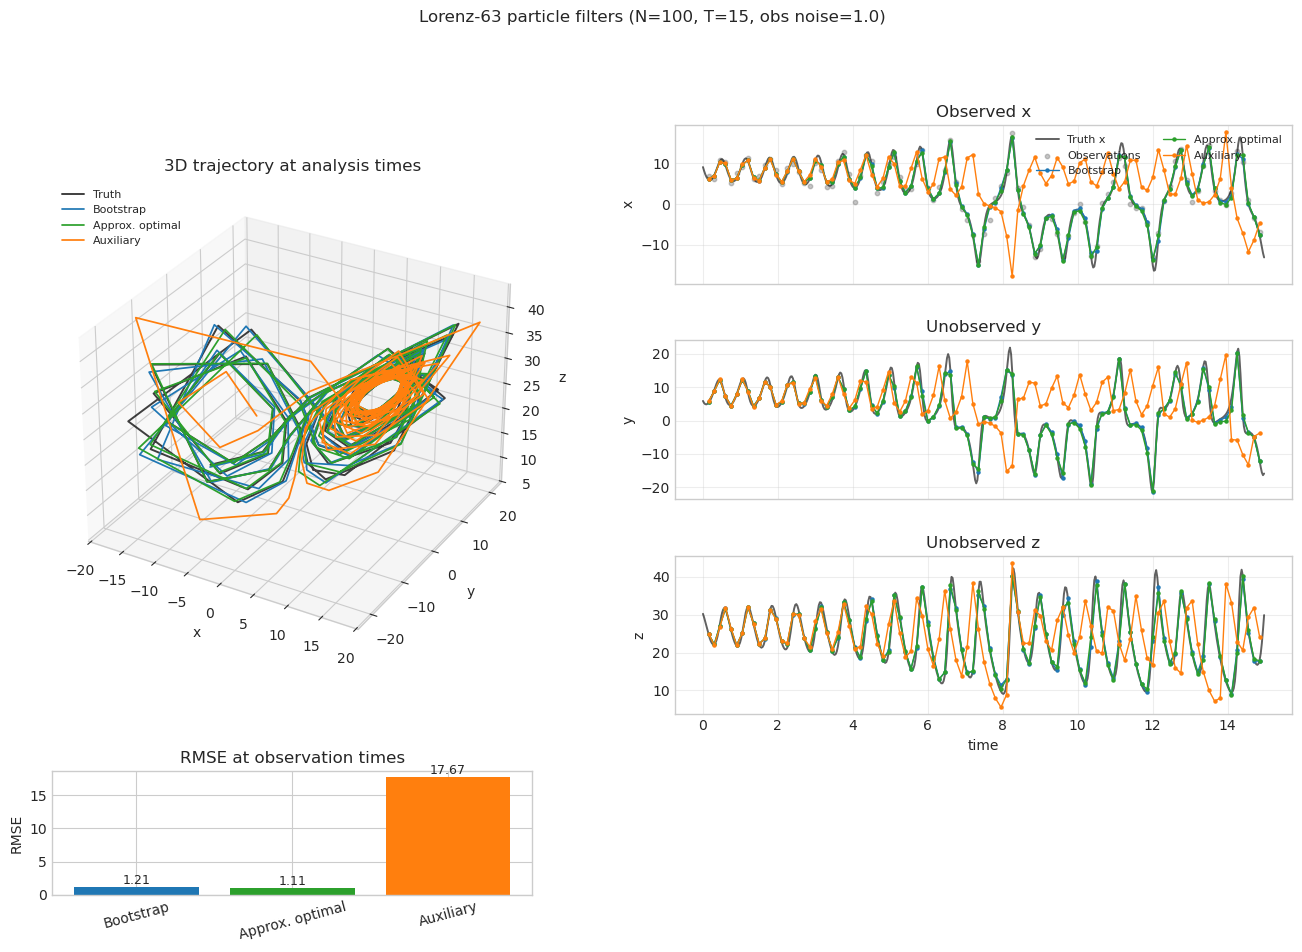

In [2]:
#@title Lorenz-63 particle-filter comparison
try:
    import torch
except ImportError:
    torch = None
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
np.set_printoptions(precision=4, suppress=True)

TORCH_AVAILABLE = torch is not None
TORCH_GPU_AVAILABLE = bool(TORCH_AVAILABLE and torch.cuda.is_available())
TORCH_DEVICE = torch.device("cuda") if TORCH_GPU_AVAILABLE else (torch.device("cpu") if TORCH_AVAILABLE else None)
TORCH_DTYPE = torch.float64 if TORCH_AVAILABLE else None


def as_torch(x, device=None, dtype=None):
    if not TORCH_AVAILABLE:
        raise RuntimeError("PyTorch is not available in this environment.")
    if device is None:
        device = TORCH_DEVICE
    if dtype is None:
        dtype = TORCH_DTYPE
    return torch.as_tensor(x, device=device, dtype=dtype)


def symmetrize_torch(M):
    return 0.5 * (M + M.T)


def mvn_sample_torch(mean, cov, size=None, generator=None, eps=1e-9):
    mean = as_torch(mean)
    cov = as_torch(cov, device=mean.device, dtype=mean.dtype)
    cov = symmetrize_torch(cov)
    w, V = torch.linalg.eigh(cov)
    w = torch.clamp(w, min=eps)
    sqrt_cov = (V * torch.sqrt(w)) @ V.T
    d = mean.shape[0]
    if size is None:
        z = torch.randn(d, device=mean.device, dtype=mean.dtype, generator=generator)
        return mean + sqrt_cov @ z
    z = torch.randn((size, d), device=mean.device, dtype=mean.dtype, generator=generator)
    return z @ sqrt_cov.T + mean


def gaussian_logpdf_torch(x, mean, cov):
    x = as_torch(x).reshape(-1)
    mean = as_torch(mean, device=x.device, dtype=x.dtype).reshape(-1)
    cov = as_torch(cov, device=x.device, dtype=x.dtype)
    cov = symmetrize_torch(cov)
    d = x.shape[0]
    xc = x - mean
    sign, logdet = torch.linalg.slogdet(cov)
    if sign.item() <= 0:
        cov = cov + 1e-9 * torch.eye(cov.shape[0], device=cov.device, dtype=cov.dtype)
        _, logdet = torch.linalg.slogdet(cov)
    quad = xc @ torch.linalg.pinv(cov) @ xc
    const = torch.log(torch.tensor(2.0 * np.pi, device=x.device, dtype=x.dtype))
    return -0.5 * (d * const + logdet + quad)


def gaussian_logpdf_batch_torch(x, means, cov):
    means = as_torch(means)
    x = as_torch(x, device=means.device, dtype=means.dtype).reshape(1, -1)
    cov = as_torch(cov, device=means.device, dtype=means.dtype)
    cov = symmetrize_torch(cov)

    d = means.shape[1]
    xc = means - x
    sign, logdet = torch.linalg.slogdet(cov)
    if sign.item() <= 0:
        cov = cov + 1e-9 * torch.eye(cov.shape[0], device=cov.device, dtype=cov.dtype)
        _, logdet = torch.linalg.slogdet(cov)
    cov_inv = torch.linalg.pinv(cov)
    quad = torch.sum((xc @ cov_inv) * xc, dim=1)
    const = torch.log(torch.tensor(2.0 * np.pi, device=means.device, dtype=means.dtype))
    return -0.5 * (d * const + logdet + quad)


def normalize_logweights_torch(logw):
    m = torch.max(logw)
    w = torch.exp(logw - m)
    s = torch.sum(w)
    if (not torch.isfinite(s).item()) or (s.item() <= 0):
        return torch.ones_like(logw) / logw.numel()
    return w / s


def systematic_resample_torch(weights, generator=None):
    n = weights.numel()
    u0 = torch.rand((), device=weights.device, dtype=weights.dtype, generator=generator)
    u = (u0 + torch.arange(n, device=weights.device, dtype=weights.dtype)) / n
    cdf = torch.cumsum(weights, dim=0)
    idx = torch.searchsorted(cdf, u, right=True)
    return torch.clamp(idx, 0, n - 1).long()


def lorenz63_rhs_torch(x, sigma=10.0, rho=28.0, beta=8.0 / 3.0):
    xx = x[..., 0]
    yy = x[..., 1]
    zz = x[..., 2]
    return torch.stack([
        sigma * (yy - xx),
        xx * (rho - zz) - yy,
        xx * yy - beta * zz,
    ], dim=-1)


def lorenz63_step_torch(x, dt=0.03):
    k1 = lorenz63_rhs_torch(x)
    k2 = lorenz63_rhs_torch(x + 0.5 * dt * k1)
    k3 = lorenz63_rhs_torch(x + 0.5 * dt * k2)
    k4 = lorenz63_rhs_torch(x + dt * k3)
    return x + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)



def symmetrize(M):
    return 0.5 * (M + M.T)


def sqrtm_psd(M, eps=1e-12):
    w, V = np.linalg.eigh(symmetrize(M))
    w = np.clip(w, eps, None)
    return (V * np.sqrt(w)) @ V.T


def invsqrtm_psd(M, eps=1e-12):
    w, V = np.linalg.eigh(symmetrize(M))
    w = np.clip(w, eps, None)
    return (V * (1.0 / np.sqrt(w))) @ V.T


def gaussian_logpdf(x, mean, cov):
    x = np.atleast_1d(x)
    mean = np.atleast_1d(mean)
    cov = np.atleast_2d(cov)
    d = x.shape[0]
    xc = x - mean
    sign, logdet = np.linalg.slogdet(cov)
    if sign <= 0:
        cov = cov + 1e-9 * np.eye(cov.shape[0])
        sign, logdet = np.linalg.slogdet(cov)
    quad = xc @ np.linalg.pinv(cov) @ xc
    return -0.5 * (d * np.log(2.0 * np.pi) + logdet + quad)


def normalize_logweights(logw):
    m = np.max(logw)
    w = np.exp(logw - m)
    s = np.sum(w)
    if (not np.isfinite(s)) or s <= 0:
        return np.ones_like(logw) / len(logw)
    return w / s


def systematic_resample(weights, rng):
    n = len(weights)
    u = (rng.random() + np.arange(n)) / n
    cdf = np.cumsum(weights)
    idx = np.searchsorted(cdf, u, side="right")
    return np.clip(idx, 0, n - 1)


def make_rotation(theta):
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[c, -s], [s, c]])


def sample_linear_initial(rng, d=2):
    m0 = rng.multivariate_normal(np.zeros(d), np.eye(d))
    v0 = rng.multivariate_normal(m0, np.eye(d))
    return v0, m0


def simulate_linear_gaussian_2d(T=80, theta=0.3, sigma_v=0.01, sigma_y=1.0, seed=0):
    rng = np.random.default_rng(seed)
    A = make_rotation(theta)
    H = np.array([[1.0, 0.0]])
    Sigma = (sigma_v ** 2) * np.eye(2)
    Gamma = np.array([[sigma_y ** 2]])

    truth = np.zeros((T, 2))
    obs = np.zeros((T, 1))

    v, _ = sample_linear_initial(rng, d=2)
    for k in range(T):
        v = A @ v + rng.multivariate_normal(np.zeros(2), Sigma)
        y = H @ v + rng.multivariate_normal(np.zeros(1), Gamma)
        truth[k] = v
        obs[k] = y

    return truth, obs, A, H, Sigma, Gamma


def lorenz63_rhs(x, sigma=10.0, rho=28.0, beta=8.0 / 3.0):
    xx, yy, zz = x
    return np.array([
        sigma * (yy - xx),
        xx * (rho - zz) - yy,
        xx * yy - beta * zz,
    ])


def lorenz63_step(x, dt=0.03):
    k1 = lorenz63_rhs(x)
    k2 = lorenz63_rhs(x + 0.5 * dt * k1)
    k3 = lorenz63_rhs(x + 0.5 * dt * k2)
    k4 = lorenz63_rhs(x + dt * k3)
    return x + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)


def lorenz63_burnin_initial(rng, dt=0.03, burn_steps=100):
    m0 = rng.multivariate_normal(np.zeros(3), np.eye(3))
    x = m0.copy()
    for _ in range(burn_steps):
        x = lorenz63_step(x, dt)
    x0 = x.copy()
    v0 = rng.multivariate_normal(x0, np.eye(3))
    return v0, m0, x0


def simulate_lorenz63(T=10.0, dt=0.03, Delta_t=0.15, sigma_v=0.01, sigma_y=1.0, burn_steps=100, seed=0):
    rng = np.random.default_rng(seed)
    n_steps = max(int(T / dt), 1)

    truth = np.zeros((n_steps, 3))
    x, _, _ = lorenz63_burnin_initial(rng, dt=dt, burn_steps=burn_steps)
    # Burn-in states are discarded; truth[0] is the first post-burn-in state.

    for t in range(n_steps):
        x = lorenz63_step(x, dt)
        if sigma_v > 0:
            x = x + rng.normal(0.0, sigma_v, size=3)
        truth[t] = x

    obs_gap = max(int(round(Delta_t / dt)), 1)
    obs_idx = [0]  # Observe first dimension only
    obs_times = np.arange(obs_gap, n_steps, obs_gap)
    Gamma = (sigma_y ** 2) * np.eye(len(obs_idx))
    obs = truth[obs_times][:, obs_idx] + rng.multivariate_normal(np.zeros(len(obs_idx)), Gamma, size=len(obs_times))

    return truth, obs, obs_times, obs_idx


# -------------------------------------------------------------------------
# Particle Filter Runners (using your provided helper functions)
# -------------------------------------------------------------------------

def run_pf_linear_torch(obs, A, H, Sigma, Gamma, N, method, use_true_init, truth_x0, seed, progress_bar=None):
    device = torch.device("cuda")
    torch.manual_seed(int(seed))
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(int(seed))

    obs_t = as_torch(obs, device=device)
    A_t = as_torch(A, device=device)
    H_t = as_torch(H, device=device)
    Sigma_t = as_torch(Sigma, device=device)
    Gamma_t = as_torch(Gamma, device=device)
    truth_x0_t = as_torch(truth_x0, device=device)

    T = obs_t.shape[0]
    d = A_t.shape[0]

    if use_true_init:
        particles = mvn_sample_torch(truth_x0_t, torch.eye(d, device=device, dtype=obs_t.dtype), size=N)
    else:
        epsilon = torch.randn(d, device=device, dtype=obs_t.dtype)
        perturbed_x0 = truth_x0_t * (1.0 + 0.3 * epsilon)
        particles = mvn_sample_torch(perturbed_x0, torch.eye(d, device=device, dtype=obs_t.dtype), size=N)

    weights = torch.full((N,), 1.0 / N, device=device, dtype=obs_t.dtype)
    est = torch.zeros((T, d), device=device, dtype=obs_t.dtype)

    Sigma_inv = torch.linalg.pinv(Sigma_t)
    Gamma_inv = torch.linalg.pinv(Gamma_t)
    C_opt = torch.linalg.pinv(Sigma_inv + H_t.T @ Gamma_inv @ H_t)
    S_pred = H_t @ Sigma_t @ H_t.T + Gamma_t

    zeros_d = torch.zeros(d, device=device, dtype=obs_t.dtype)

    for k in range(T):
        y = obs_t[k].reshape(-1)

        if method == "bootstrap":
            pred_mean = particles @ A_t.T
            prop = pred_mean + mvn_sample_torch(zeros_d, Sigma_t, size=N)
            logw = torch.log(weights + 1e-300)
            logw = logw + gaussian_logpdf_batch_torch(y, prop @ H_t.T, Gamma_t)
            particles = prop

        elif method == "optimal":
            prev = particles.clone()
            pred_mean = prev @ A_t.T
            prop = torch.zeros_like(prev)
            logw = torch.log(weights + 1e-300)
            obs_term = H_t.T @ Gamma_inv @ y

            for i in range(N):
                m_star = C_opt @ (Sigma_inv @ pred_mean[i] + obs_term)
                prop[i] = mvn_sample_torch(m_star, C_opt)

            logw = logw + gaussian_logpdf_batch_torch(y, pred_mean @ H_t.T, S_pred)
            particles = prop

        elif method == "auxiliary":
            prev = particles.clone()
            pred_mean = prev @ A_t.T

            first_logw = torch.log(weights + 1e-300)
            first_logw = first_logw + gaussian_logpdf_batch_torch(y, pred_mean @ H_t.T, S_pred)
            first_w = normalize_logweights_torch(first_logw)
            ancestors = torch.multinomial(first_w, N, replacement=True)

            anc_mean = pred_mean[ancestors]
            prop = anc_mean + mvn_sample_torch(zeros_d, Sigma_t, size=N)

            logw = gaussian_logpdf_batch_torch(y, prop @ H_t.T, Gamma_t)
            logw = logw - gaussian_logpdf_batch_torch(y, anc_mean @ H_t.T, S_pred)
            particles = prop
        else:
            raise ValueError(f"Unknown method: {method}")

        weights = normalize_logweights_torch(logw)
        est[k] = torch.sum(weights[:, None] * particles, dim=0)

        ess = 1.0 / torch.sum(weights ** 2)
        if ess.item() < 0.5 * N:
            idx = systematic_resample_torch(weights)
            particles = particles[idx]
            weights.fill_(1.0 / N)

        if progress_bar:
            progress_bar.value += 1

    return est.detach().cpu().numpy()


def run_pf_linear(obs, A, H, Sigma, Gamma, N, method, use_true_init, truth_x0, seed, progress_bar=None):
    """
    Particle Filter for Linear-Gaussian system using provided helper functions.
    input: obs (T, d_obs), system matrices, N (particles), method (str), init flags, truth_x0 (d,), seed
    output: est (T, d) state estimates
    """
    if TORCH_GPU_AVAILABLE:
        return run_pf_linear_torch(obs, A, H, Sigma, Gamma, N, method, use_true_init, truth_x0, seed, progress_bar=progress_bar)

    rng = np.random.default_rng(seed)
    T = len(obs)
    d = A.shape[0]

    # Initialization
    if use_true_init:
        # N(v0, I)
        particles = rng.multivariate_normal(truth_x0, np.eye(d), size=N)
    else:
        # v0_tilde = v0 * (1 + 0.3 * epsilon), epsilon ~ N(0, I)
        epsilon = rng.standard_normal(size=d)
        perturbed_x0 = truth_x0 * (1 + 0.3 * epsilon)
        particles = rng.multivariate_normal(perturbed_x0, np.eye(d), size=N)

    weights = np.ones(N) / N
    est = np.zeros((T, d))

    # Pre-compute matrices for Optimal PF (Linear Case)
    Sigma_inv = np.linalg.pinv(Sigma)
    Gamma_inv = np.linalg.pinv(Gamma)
    # C_opt: Posterior covariance for the optimal proposal
    C_opt = np.linalg.pinv(Sigma_inv + H.T @ Gamma_inv @ H)
    # S_pred: Predictive covariance p(y_t | x_{t-1})
    S_pred = H @ Sigma @ H.T + Gamma

    for k in range(T):
        y = obs[k]

        # --- Bootstrap PF ---
        if method == "bootstrap":
            # Prediction: x_t = A x_{t-1}
            pred_mean = particles @ A.T
            # Propagate noise
            prop = pred_mean + rng.multivariate_normal(np.zeros(d), Sigma, size=N)

            # Weight update
            logw = np.log(weights + 1e-300)
            for i in range(N):
                logw[i] += gaussian_logpdf(y, H @ prop[i], Gamma)
            particles = prop

        # --- Optimal PF (Exact) ---
        elif method == "optimal":
            prev = particles.copy()
            pred_mean = prev @ A.T
            prop = np.zeros_like(prev)
            logw = np.log(weights + 1e-300)

            for i in range(N):
                # Optimal proposal mean: m* = C_opt (Sigma^-1 A x_{t-1} + H^T Gamma^-1 y_t)
                m_star = C_opt @ (Sigma_inv @ pred_mean[i] + H.T @ Gamma_inv @ y)
                prop[i] = rng.multivariate_normal(m_star, C_opt)

                # Weight update uses predictive density directly
                logw[i] += gaussian_logpdf(y, H @ pred_mean[i], S_pred)
            particles = prop

        # --- Auxiliary PF ---
        elif method == "auxiliary":
            prev = particles.copy()
            pred_mean = prev @ A.T

            # 1. Lookahead / Pilot weights
            first_logw = np.log(weights + 1e-300)
            for i in range(N):
                first_logw[i] += gaussian_logpdf(y, H @ pred_mean[i], S_pred)

            # 2. Resample indices (Auxiliary variable)
            first_w = normalize_logweights(first_logw)
            ancestors = rng.choice(N, size=N, p=first_w)

            anc_mean = pred_mean[ancestors]

            # 3. Propagate
            prop = anc_mean + rng.multivariate_normal(np.zeros(d), Sigma, size=N)

            # 4. Correct weights
            logw = np.zeros(N)
            for i in range(N):
                likelihood = gaussian_logpdf(y, H @ prop[i], Gamma)
                prior = gaussian_logpdf(y, H @ anc_mean[i], S_pred)
                logw[i] = likelihood - prior
            particles = prop

        # Estimate and ESS
        weights = normalize_logweights(logw)
        est[k] = np.sum(weights[:, None] * particles, axis=0)

        # Resampling check
        ess = 1.0 / np.sum(weights ** 2)
        if ess < 0.5 * N:
            idx = systematic_resample(weights, rng)
            particles = particles[idx]
            weights.fill(1.0 / N)

        if progress_bar:
            progress_bar.value += 1

    return est


def run_pf_lorenz_torch(obs, obs_times, obs_idx, dt, sigma_v, sigma_y, N, method, use_true_init, truth_x0, seed, progress_bar=None):
    device = torch.device("cuda")
    torch.manual_seed(int(seed))
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(int(seed))

    T_obs = len(obs)
    d = 3

    H_t = torch.zeros((len(obs_idx), d), device=device, dtype=TORCH_DTYPE)
    for r, c in enumerate(obs_idx):
        H_t[r, c] = 1.0

    Gamma_t = (sigma_y ** 2) * torch.eye(len(obs_idx), device=device, dtype=TORCH_DTYPE)
    Gamma_inv = torch.linalg.pinv(Gamma_t)

    obs_gap = int(obs_times[0]) if len(obs_times) > 0 else 1
    Q_val = max(obs_gap * (sigma_v ** 2), 1e-6)
    Q_t = Q_val * torch.eye(d, device=device, dtype=TORCH_DTYPE)
    Q_inv = torch.linalg.pinv(Q_t)
    C_opt = torch.linalg.pinv(Q_inv + H_t.T @ Gamma_inv @ H_t)
    S_pred = H_t @ Q_t @ H_t.T + Gamma_t

    truth_x0_t = as_torch(truth_x0, device=device, dtype=TORCH_DTYPE)
    if use_true_init:
        particles = mvn_sample_torch(truth_x0_t, torch.eye(d, device=device, dtype=TORCH_DTYPE), size=N)
    else:
        epsilon = torch.randn(d, device=device, dtype=TORCH_DTYPE)
        perturbed_x0 = truth_x0_t * (1.0 + 0.3 * epsilon)
        particles = mvn_sample_torch(perturbed_x0, torch.eye(d, device=device, dtype=TORCH_DTYPE), size=N)

    obs_t = as_torch(obs, device=device, dtype=TORCH_DTYPE)
    weights = torch.full((N,), 1.0 / N, device=device, dtype=TORCH_DTYPE)
    est = torch.zeros((T_obs, d), device=device, dtype=TORCH_DTYPE)
    current_time_step = 0

    for k in range(T_obs):
        target_time_step = int(obs_times[k])
        steps_to_sim = max(target_time_step - current_time_step, 0)
        y = obs_t[k].reshape(-1)

        prev = particles.clone()
        pred_mean = prev.clone()
        for _ in range(steps_to_sim):
            pred_mean = lorenz63_step_torch(pred_mean, dt)

        if method == "bootstrap":
            prop = prev.clone()
            for _ in range(steps_to_sim):
                prop = lorenz63_step_torch(prop, dt)
                if sigma_v > 0:
                    prop = prop + sigma_v * torch.randn_like(prop)

            logw = torch.log(weights + 1e-300)
            logw = logw + gaussian_logpdf_batch_torch(y, prop @ H_t.T, Gamma_t)
            particles = prop

        elif method == "optimal_3dvar":
            prop = torch.zeros_like(prev)
            logw = torch.log(weights + 1e-300)
            obs_term = H_t.T @ Gamma_inv @ y

            for i in range(N):
                m_star = C_opt @ (Q_inv @ pred_mean[i] + obs_term)
                prop[i] = mvn_sample_torch(m_star, C_opt)

            logw = logw + gaussian_logpdf_batch_torch(y, pred_mean @ H_t.T, S_pred)
            particles = prop

        elif method == "auxiliary":
            first_logw = torch.log(weights + 1e-300)
            first_logw = first_logw + gaussian_logpdf_batch_torch(y, pred_mean @ H_t.T, S_pred)

            first_w = normalize_logweights_torch(first_logw)
            ancestors = torch.multinomial(first_w, N, replacement=True)

            anc_mean = pred_mean[ancestors]
            anc_particles = prev[ancestors]

            prop = anc_particles.clone()
            for _ in range(steps_to_sim):
                prop = lorenz63_step_torch(prop, dt)
                if sigma_v > 0:
                    prop = prop + sigma_v * torch.randn_like(prop)

            logw = gaussian_logpdf_batch_torch(y, prop @ H_t.T, Gamma_t)
            logw = logw - gaussian_logpdf_batch_torch(y, anc_mean @ H_t.T, S_pred)
            particles = prop
        else:
            raise ValueError(f"Unknown method: {method}")

        weights = normalize_logweights_torch(logw)
        est[k] = torch.sum(weights[:, None] * particles, dim=0)

        if (1.0 / torch.sum(weights ** 2)).item() < 0.5 * N:
            idx = systematic_resample_torch(weights)
            particles = particles[idx]
            weights.fill_(1.0 / N)

        current_time_step = target_time_step

        if progress_bar:
            progress_bar.value += 1

    return est.detach().cpu().numpy()


def run_pf_lorenz(obs, obs_times, obs_idx, dt, sigma_v, sigma_y, N, method, use_true_init, truth_x0, seed, progress_bar=None):
    """
    Particle Filter for Lorenz-63 using the provided RK4 'lorenz63_step'.
    input: obs, times, indices, system params, N, method, init flags, truth_x0, seed
    output: est (T_obs, 3) state estimates at observation times
    """
    if TORCH_GPU_AVAILABLE:
        return run_pf_lorenz_torch(
            obs,
            obs_times,
            obs_idx,
            dt,
            sigma_v,
            sigma_y,
            N,
            method,
            use_true_init,
            truth_x0,
            seed,
            progress_bar=progress_bar,
        )

    rng = np.random.default_rng(seed)
    T_obs = len(obs)
    d = 3 # State dimension

    # Construct H based on obs_idx (e.g., [0] -> [[1, 0, 0]])
    H = np.zeros((len(obs_idx), d))
    for r, c in enumerate(obs_idx):
        H[r, c] = 1.0

    Gamma = (sigma_y ** 2) * np.eye(len(obs_idx))
    Gamma_inv = np.linalg.pinv(Gamma)

    # Calculate obs_gap from times (assuming uniform gap)
    obs_gap = obs_times[0] if len(obs_times) > 0 else 1

    # Approximate Q for proposal design (Linearized approx)
    Q_val = max(obs_gap * (sigma_v**2), 1e-6)
    Q = Q_val * np.eye(d)
    Q_inv = np.linalg.pinv(Q)

    # Pre-calc approximate optimal matrices
    C_opt = np.linalg.pinv(Q_inv + H.T @ Gamma_inv @ H)
    S_pred = H @ Q @ H.T + Gamma

    # Initialization
    if use_true_init:
        particles = rng.multivariate_normal(truth_x0, np.eye(d), size=N)
    else:
        # v0_tilde = v0 * (1 + 0.3 * epsilon), epsilon ~ N(0, I)
        epsilon = rng.standard_normal(size=d)
        perturbed_x0 = truth_x0 * (1 + 0.3 * epsilon)
        particles = rng.multivariate_normal(perturbed_x0, np.eye(d), size=N)

    weights = np.ones(N) / N
    est = np.zeros((T_obs, d))

    current_time_step = 0

    for k in range(T_obs):
        target_time_step = obs_times[k]
        steps_to_sim = target_time_step - current_time_step
        y = np.atleast_1d(obs[k])

        prev = particles.copy()
        pred_mean = np.zeros_like(prev)

        # 1. Deterministic Forecast (for mean-based proposals)
        # We use the provided lorenz63_step (RK4)
        for i in range(N):
            temp = prev[i]
            for _ in range(steps_to_sim):
                temp = lorenz63_step(temp, dt)
            pred_mean[i] = temp

        # --- Bootstrap ---
        if method == "bootstrap":
            prop = np.zeros_like(prev)
            for i in range(N):
                temp = prev[i]
                for _ in range(steps_to_sim):
                    temp = lorenz63_step(temp, dt)
                    if sigma_v > 0:
                        temp += rng.normal(0, sigma_v, size=d)
                prop[i] = temp

            logw = np.log(weights + 1e-300)
            for i in range(N):
                logw[i] += gaussian_logpdf(y, H @ prop[i], Gamma)
            particles = prop

        # --- Optimal (Approx 3DVar) ---
        elif method == "optimal_3dvar":
            prop = np.zeros_like(prev)
            logw = np.log(weights + 1e-300)

            for i in range(N):
                # Use the deterministic forecast 'pred_mean' as the prior mean for this step
                m_star = C_opt @ (Q_inv @ pred_mean[i] + H.T @ Gamma_inv @ y)
                prop[i] = rng.multivariate_normal(m_star, C_opt)
                logw[i] += gaussian_logpdf(y, H @ pred_mean[i], S_pred)
            particles = prop

        # --- Auxiliary ---
        elif method == "auxiliary":
            # Stage 1: Weight based on predictive mean
            first_logw = np.log(weights + 1e-300)
            for i in range(N):
                first_logw[i] += gaussian_logpdf(y, H @ pred_mean[i], S_pred)

            first_w = normalize_logweights(first_logw)
            ancestors = rng.choice(N, size=N, p=first_w)

            anc_mean = pred_mean[ancestors]
            anc_particles = prev[ancestors]

            # Stage 2: Propagate ancestors
            prop = np.zeros_like(prev)
            for i in range(N):
                temp = anc_particles[i]
                for _ in range(steps_to_sim):
                    temp = lorenz63_step(temp, dt)
                    if sigma_v > 0:
                        temp += rng.normal(0, sigma_v, size=d)
                prop[i] = temp

            # Stage 3: Reweight
            logw = np.zeros(N)
            for i in range(N):
                lik = gaussian_logpdf(y, H @ prop[i], Gamma)
                prior = gaussian_logpdf(y, H @ anc_mean[i], S_pred)
                logw[i] = lik - prior
            particles = prop

        # Estimate
        weights = normalize_logweights(logw)
        est[k] = np.sum(weights[:, None] * particles, axis=0)

        # Resample
        if 1.0 / np.sum(weights**2) < 0.5 * N:
            idx = systematic_resample(weights, rng)
            particles = particles[idx]
            weights.fill(1.0 / N)

        # Update state
        current_time_step = target_time_step

        if progress_bar:
            progress_bar.value += 1

    return est

DEFAULT_PARAMETERS = {
    "lorenz_particle_filter": {
        "total_time": 15.0,
        "dt": 0.03,
        "assimilation_time_step": 0.15,
        "dynamics_noise_std": 0.01,
        "observation_noise_std": 1.0,
        "n_particles": 100,
        "use_true_initialization": True,
        "burn_steps": 100,
        "seed": 99,
    },
}

use_default = False #@param {type:"boolean"}
n_particles = 100 #@param {type:"slider", min:100, max:1000, step:100}
total_time = 15.0 #@param {type:"slider", min:15.0, max:45.0, step:5.0}
observation_noise_std = 1.0 #@param {type:"slider", min:0.2, max:3.0, step:0.1}
use_true_initialization = True #@param {type:"boolean"}

params = DEFAULT_PARAMETERS["lorenz_particle_filter"].copy()
if not use_default:
    params.update({
        "n_particles": int(n_particles),
        "total_time": float(total_time),
        "observation_noise_std": float(observation_noise_std),
        "use_true_initialization": bool(use_true_initialization),
    })

truth_full, obs, obs_times, obs_idx = simulate_lorenz63(
    T=params["total_time"],
    dt=params["dt"],
    Delta_t=params["assimilation_time_step"],
    sigma_v=params["dynamics_noise_std"],
    sigma_y=params["observation_noise_std"],
    burn_steps=params["burn_steps"],
    seed=params["seed"],
)
truth_at_obs = truth_full[obs_times]
methods = [
    ("Bootstrap", "bootstrap", "tab:blue"),
    ("Approx. optimal", "optimal_3dvar", "tab:green"),
    ("Auxiliary", "auxiliary", "tab:orange"),
]

results = []
rmses = []
for name, method_code, color in methods:
    est = run_pf_lorenz(
        obs,
        obs_times,
        obs_idx,
        params["dt"],
        params["dynamics_noise_std"],
        params["observation_noise_std"],
        params["n_particles"],
        method_code,
        params["use_true_initialization"],
        truth_full[0],
        seed=params["seed"] + 50,
    )
    rmse = np.sqrt(np.mean(np.sum((est - truth_at_obs) ** 2, axis=1)))
    results.append((name, est, color))
    rmses.append(rmse)

print("Effective parameters:")
for key, value in params.items():
    print(f"  {key}: {value}")
print("\nRMSE at observation times:")
for (name, _, _), rmse in zip(results, rmses):
    print(f"  {name}: {rmse:.3f}")

t_full = np.arange(len(truth_full)) * params["dt"]
t_obs = obs_times * params["dt"]
component_names = ["Observed x", "Unobserved y", "Unobserved z"]
component_symbols = ["x", "y", "z"]

fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(
    4,
    2,
    width_ratios=[1.05, 1.35],
    height_ratios=[1.0, 1.0, 1.0, 0.78],
    hspace=0.38,
    wspace=0.26,
)

ax3d = fig.add_subplot(gs[:3, 0], projection="3d")
ax3d.plot(truth_at_obs[:, 0], truth_at_obs[:, 1], truth_at_obs[:, 2], "k-", lw=1.4, alpha=0.75, label="Truth")
for name, est, color in results:
    ax3d.plot(est[:, 0], est[:, 1], est[:, 2], color=color, lw=1.25, label=name)
ax3d.set_title("3D trajectory at analysis times")
ax3d.set_xlabel("x")
ax3d.set_ylabel("y")
ax3d.set_zlabel("z")
ax3d.legend(loc="upper left", fontsize=8)

ax_rmse = fig.add_subplot(gs[3, 0])
bars = ax_rmse.bar([name for name, _, _ in results], rmses, color=[color for _, _, color in results])
ax_rmse.set_title("RMSE at observation times")
ax_rmse.set_ylabel("RMSE")
ax_rmse.tick_params(axis="x", labelrotation=15)
for bar in bars:
    height = bar.get_height()
    ax_rmse.text(bar.get_x() + bar.get_width() / 2, height, f"{height:.2f}", ha="center", va="bottom", fontsize=9)

traj_axes = [fig.add_subplot(gs[row, 1]) for row in range(3)]
for dim, ax in enumerate(traj_axes):
    ax.plot(t_full, truth_full[:, dim], "k-", lw=1.4, alpha=0.62, label=f"Truth {component_symbols[dim]}")
    if dim == 0:
        ax.scatter(t_obs, obs[:, 0], c="gray", s=10, alpha=0.45, label="Observations")
    for name, est, color in results:
        ax.plot(t_obs, est[:, dim], color=color, marker="o", markersize=2.2, lw=1.0, label=name)
    ax.set_title(component_names[dim])
    ax.set_ylabel(component_symbols[dim])
    ax.grid(True, alpha=0.35)
    if dim == 2:
        ax.set_xlabel("time")
    else:
        ax.tick_params(labelbottom=False)
    if dim == 0:
        ax.legend(loc="upper right", ncol=2, fontsize=8)

fig.suptitle(
    f"Lorenz-63 particle filters (N={params['n_particles']}, T={params['total_time']:.0f}, obs noise={params['observation_noise_std']:.1f})",
    y=0.995,
)
plt.show()
